# Energy Forecast PT - Análise Exploratória Avançada

Análise exploratória detalhada dos dados de consumo energético em Portugal.

**Objetivos:**
- 📊 Decomposição sazonal (tendência, sazonalidade, resíduos)
- 🔍 Detecção de outliers e anomalias
- 📈 Autocorrelação (ACF/PACF) para análise temporal
- 🌡️ Análise de padrões meteorológicos por região
- 🕐 Padrões de consumo por hora/dia/mês/estação
- 🔬 Distribuições estatísticas e testes de normalidade
- 🗺️ Comparação entre regiões (clustering)

## 1. Setup e Importações

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Configuração de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print('✓ Bibliotecas carregadas')

✓ Bibliotecas carregadas


## 2. Carregamento de Dados

In [2]:
# Carregar dados processados
df = pd.read_parquet('../data/processed/processed_data.parquet')

print(f'📊 Dados carregados: {len(df):,} linhas')
print(f'📅 Período: {df["timestamp"].min()} → {df["timestamp"].max()}')
print(f'🗺️ Regiões: {df["region"].nunique()}')
print(f'📝 Colunas: {len(df.columns)}')

# Criar features temporais
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day'] = df['timestamp'].dt.day
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['week_of_year'] = df['timestamp'].dt.isocalendar().week
df['quarter'] = df['timestamp'].dt.quarter

# Criar estações do ano (Portugal)
def get_season(month):
    if month in [12, 1, 2]:
        return 'Inverno'
    elif month in [3, 4, 5]:
        return 'Primavera'
    elif month in [6, 7, 8]:
        return 'Verão'
    else:
        return 'Outono'

df['season'] = df['month'].apply(get_season)

print('\n✓ Features temporais criadas')
df.head(3)

📊 Dados carregados: 175,205 linhas
📅 Período: 2021-01-01 00:00:00 → 2024-12-31 00:00:00
🗺️ Regiões: 5
📝 Colunas: 37

✓ Features temporais criadas


,timestamp,region,consumption_mw,city,latitude,longitude,temperature,temperature_feels_like,humidity,wind_speed,...,cos_hour,sin_day_of_week,cos_day_of_week,sin_month,cos_month,sin_day_of_year,cos_day_of_year,year,day,season
0,2021-01-01 00:00:00,Alentejo,315.298341,Évora,38.57,-7.91,8.564195,8.053474,100.000000,10.214426,...,1.000000,-0.433884,-0.900969,0.5,0.866025,0.017213,0.999852,2021,1,Inverno
1,2021-01-01 01:00:00,Alentejo,293.386521,Évora,38.57,-7.91,8.312618,7.582371,91.629073,14.604951,...,0.965926,-0.433884,-0.900969,0.5,0.866025,0.017213,0.999852,2021,1,Inverno
2,2021-01-01 02:00:00,Alentejo,413.913511,Évora,38.57,-7.91,9.745539,9.105850,90.211741,12.793783,...,0.866025,-0.433884,-0.900969,0.5,0.866025,0.017213,0.999852,2021,1,Inverno


## 3. Estatísticas Descritivas Completas

In [3]:
# Estatísticas básicas
print('='*80)
print('ESTATÍSTICAS DESCRITIVAS - CONSUMO ENERGÉTICO')
print('='*80)

consumption_stats = df['consumption_mw'].describe()
print(f"\nMédia: {consumption_stats['mean']:.2f} MW")
print(f"Mediana: {df['consumption_mw'].median():.2f} MW")
print(f"Desvio Padrão: {consumption_stats['std']:.2f} MW")
print(f"Coef. Variação: {(consumption_stats['std']/consumption_stats['mean']*100):.2f}%")
print(f"\nMínimo: {consumption_stats['min']:.2f} MW")
print(f"Q1 (25%): {consumption_stats['25%']:.2f} MW")
print(f"Q2 (50%): {consumption_stats['50%']:.2f} MW")
print(f"Q3 (75%): {consumption_stats['75%']:.2f} MW")
print(f"Máximo: {consumption_stats['max']:.2f} MW")
print(f"\nAmplitude: {consumption_stats['max'] - consumption_stats['min']:.2f} MW")
print(f"IQR: {consumption_stats['75%'] - consumption_stats['25%']:.2f} MW")

# Assimetria e Curtose
skewness = df['consumption_mw'].skew()
kurtosis = df['consumption_mw'].kurtosis()
print(f"\nAssimetria (Skewness): {skewness:.4f}")
print(f"Curtose (Kurtosis): {kurtosis:.4f}")

if abs(skewness) < 0.5:
    print("  → Distribuição aproximadamente simétrica")
elif skewness > 0:
    print("  → Distribuição assimétrica à direita (cauda positiva)")
else:
    print("  → Distribuição assimétrica à esquerda (cauda negativa)")

print('='*80)

ESTATÍSTICAS DESCRITIVAS - CONSUMO ENERGÉTICO

Média: 1332.59 MW
Mediana: 1146.74 MW
Desvio Padrão: 849.47 MW
Coef. Variação: 63.75%

Mínimo: 150.00 MW
Q1 (25%): 601.18 MW
Q2 (50%): 1146.74 MW
Q3 (75%): 1907.93 MW
Máximo: 4036.51 MW

Amplitude: 3886.51 MW
IQR: 1306.75 MW

Assimetria (Skewness): 0.7874
Curtose (Kurtosis): -0.3166
  → Distribuição assimétrica à direita (cauda positiva)


In [4]:
# Estatísticas por região
print('\n📍 ESTATÍSTICAS POR REGIÃO\n')
region_stats = df.groupby('region')['consumption_mw'].agg([
    ('count', 'count'),
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std'),
    ('min', 'min'),
    ('max', 'max'),
    ('cv', lambda x: x.std()/x.mean()*100)
]).round(2)

region_stats = region_stats.sort_values('mean', ascending=False)
print(region_stats)


📍 ESTATÍSTICAS POR REGIÃO

          count     mean   median     std    min      max     cv
region                                                          
Lisboa    35041  2523.87  2534.93  627.75  750.0  4036.51  24.87
Norte     35041  1816.84  1824.24  450.68  540.0  2924.83  24.81
Centro    35041  1212.01  1216.78  300.50  360.0  1918.11  24.79
Alentejo  35041   605.60   607.57  150.32  180.0   964.45  24.82
Algarve   35041   504.64   506.07  125.21  150.0   817.62  24.81


## 4. Distribuições e Testes de Normalidade

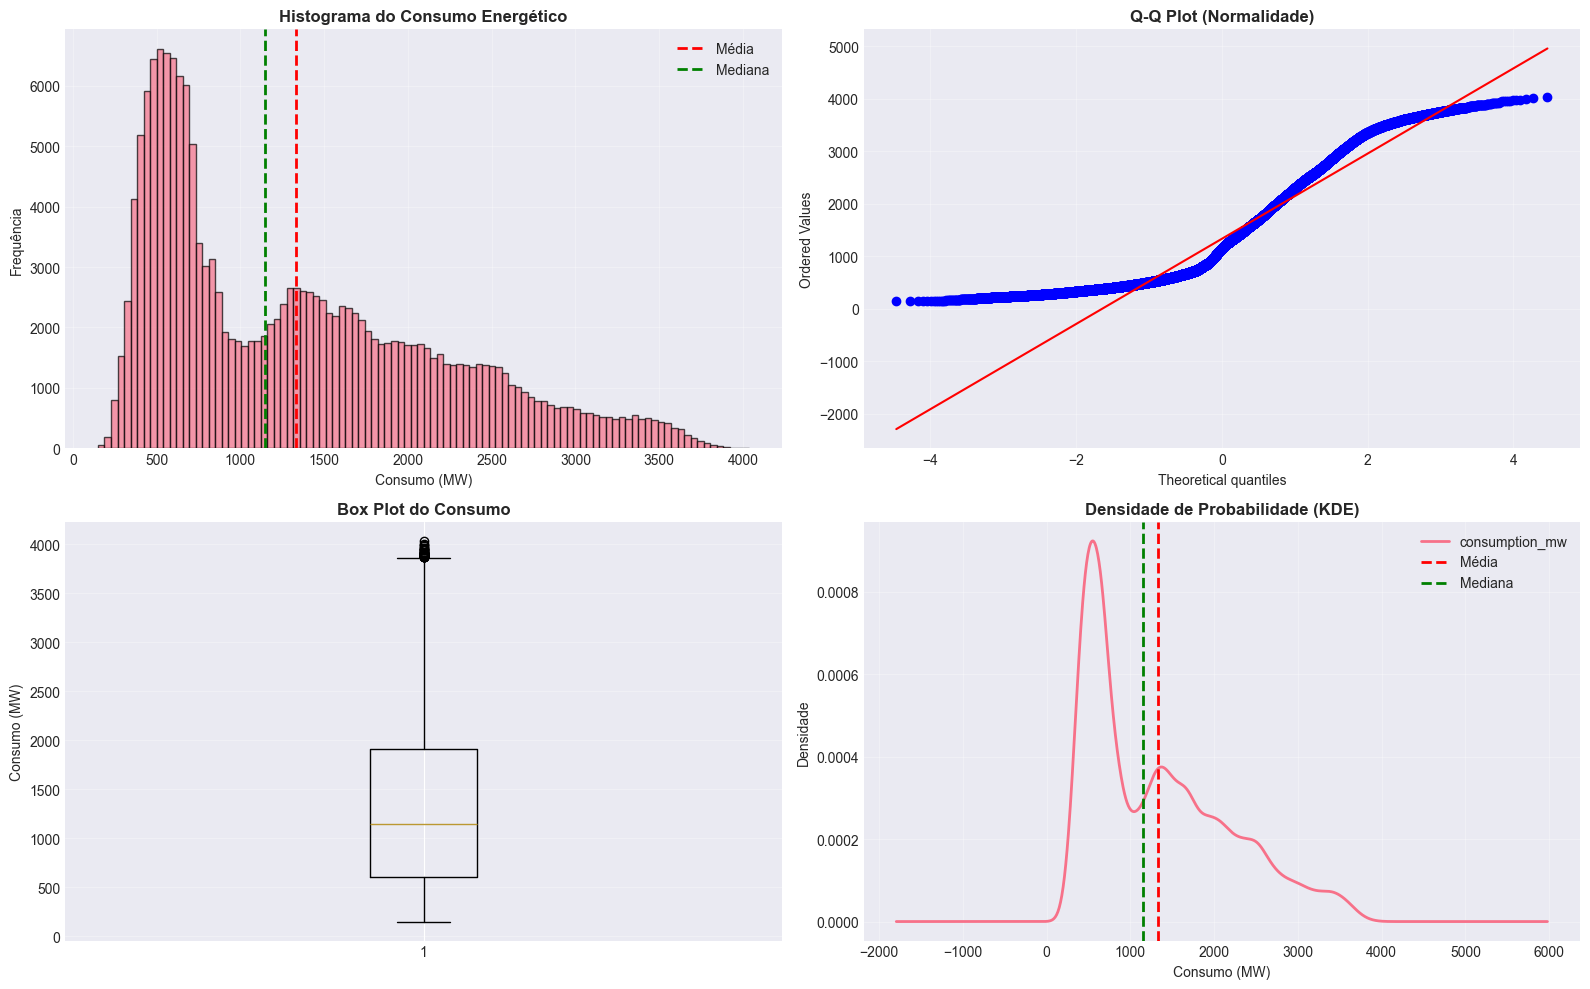


🧪 TESTES DE NORMALIDADE

Shapiro-Wilk Test (n=5000):
  Statistic: 0.908510
  P-value: 0.000000
  Resultado: Não-Normal (α=0.05)

Kolmogorov-Smirnov Test:
  Statistic: 0.132666
  P-value: 0.000000
  Resultado: Não-Normal (α=0.05)

Anderson-Darling Test:
  Statistic: 5003.048683
  Critical Values: [0.576 0.656 0.787 0.918 1.092]
  Significance Levels: [15.  10.   5.   2.5  1. ]%


In [5]:
# Visualização da distribuição
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Histograma
axes[0, 0].hist(df['consumption_mw'], bins=100, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['consumption_mw'].mean(), color='red', linestyle='--', linewidth=2, label='Média')
axes[0, 0].axvline(df['consumption_mw'].median(), color='green', linestyle='--', linewidth=2, label='Mediana')
axes[0, 0].set_title('Histograma do Consumo Energético', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Consumo (MW)')
axes[0, 0].set_ylabel('Frequência')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Q-Q Plot
stats.probplot(df['consumption_mw'], dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Normalidade)', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Box Plot
axes[1, 0].boxplot(df['consumption_mw'], vert=True)
axes[1, 0].set_title('Box Plot do Consumo', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Consumo (MW)')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# KDE Plot
df['consumption_mw'].plot(kind='kde', ax=axes[1, 1], linewidth=2)
axes[1, 1].axvline(df['consumption_mw'].mean(), color='red', linestyle='--', linewidth=2, label='Média')
axes[1, 1].axvline(df['consumption_mw'].median(), color='green', linestyle='--', linewidth=2, label='Mediana')
axes[1, 1].set_title('Densidade de Probabilidade (KDE)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Consumo (MW)')
axes[1, 1].set_ylabel('Densidade')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Testes estatísticos de normalidade
print('\n🧪 TESTES DE NORMALIDADE\n')

# Shapiro-Wilk (amostra de 5000 - limite do teste)
sample = df['consumption_mw'].sample(min(5000, len(df)), random_state=42)
shapiro_stat, shapiro_p = stats.shapiro(sample)
print(f"Shapiro-Wilk Test (n={len(sample)}):")
print(f"  Statistic: {shapiro_stat:.6f}")
print(f"  P-value: {shapiro_p:.6f}")
print(f"  Resultado: {'Normal' if shapiro_p > 0.05 else 'Não-Normal'} (α=0.05)\n")

# Kolmogorov-Smirnov
ks_stat, ks_p = stats.kstest(df['consumption_mw'], 'norm', args=(df['consumption_mw'].mean(), df['consumption_mw'].std()))
print(f"Kolmogorov-Smirnov Test:")
print(f"  Statistic: {ks_stat:.6f}")
print(f"  P-value: {ks_p:.6f}")
print(f"  Resultado: {'Normal' if ks_p > 0.05 else 'Não-Normal'} (α=0.05)\n")

# Anderson-Darling
anderson_result = stats.anderson(df['consumption_mw'])
print(f"Anderson-Darling Test:")
print(f"  Statistic: {anderson_result.statistic:.6f}")
print(f"  Critical Values: {anderson_result.critical_values}")
print(f"  Significance Levels: {anderson_result.significance_level}%")

## 5. Detecção de Outliers

In [6]:
# Múltiplos métodos de detecção de outliers
print('🔍 DETECÇÃO DE OUTLIERS\n')

# 1. Método IQR (Interquartile Range)
Q1 = df['consumption_mw'].quantile(0.25)
Q3 = df['consumption_mw'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df['consumption_mw'] < lower_bound) | (df['consumption_mw'] > upper_bound)]
print(f"1. Método IQR (1.5×IQR):")
print(f"   Limites: [{lower_bound:.2f}, {upper_bound:.2f}] MW")
print(f"   Outliers: {len(outliers_iqr):,} ({len(outliers_iqr)/len(df)*100:.2f}%)\n")

# 2. Método Z-Score (3 desvios padrão)
z_scores = np.abs(stats.zscore(df['consumption_mw']))
outliers_zscore = df[z_scores > 3]
print(f"2. Método Z-Score (|z| > 3):")
print(f"   Outliers: {len(outliers_zscore):,} ({len(outliers_zscore)/len(df)*100:.2f}%)\n")

# 3. Método Percentil (1% e 99%)
p1 = df['consumption_mw'].quantile(0.01)
p99 = df['consumption_mw'].quantile(0.99)
outliers_percentile = df[(df['consumption_mw'] < p1) | (df['consumption_mw'] > p99)]
print(f"3. Método Percentil (< P1 ou > P99):")
print(f"   Limites: [{p1:.2f}, {p99:.2f}] MW")
print(f"   Outliers: {len(outliers_percentile):,} ({len(outliers_percentile)/len(df)*100:.2f}%)\n")

# Análise de outliers por região
print('📍 Outliers por Região (IQR):')
for region in df['region'].unique():
    region_data = df[df['region'] == region]
    Q1_r = region_data['consumption_mw'].quantile(0.25)
    Q3_r = region_data['consumption_mw'].quantile(0.75)
    IQR_r = Q3_r - Q1_r
    outliers_r = region_data[
        (region_data['consumption_mw'] < Q1_r - 1.5*IQR_r) | 
        (region_data['consumption_mw'] > Q3_r + 1.5*IQR_r)
    ]
    print(f"   {region}: {len(outliers_r):,} ({len(outliers_r)/len(region_data)*100:.2f}%)")

🔍 DETECÇÃO DE OUTLIERS

1. Método IQR (1.5×IQR):
   Limites: [-1358.94, 3868.06] MW
   Outliers: 41 (0.02%)

2. Método Z-Score (|z| > 3):
   Outliers: 32 (0.02%)

3. Método Percentil (< P1 ou > P99):
   Limites: [287.72, 3532.23] MW
   Outliers: 3,506 (2.00%)

📍 Outliers por Região (IQR):
   Alentejo: 0 (0.00%)
   Algarve: 0 (0.00%)
   Centro: 0 (0.00%)
   Lisboa: 0 (0.00%)
   Norte: 0 (0.00%)


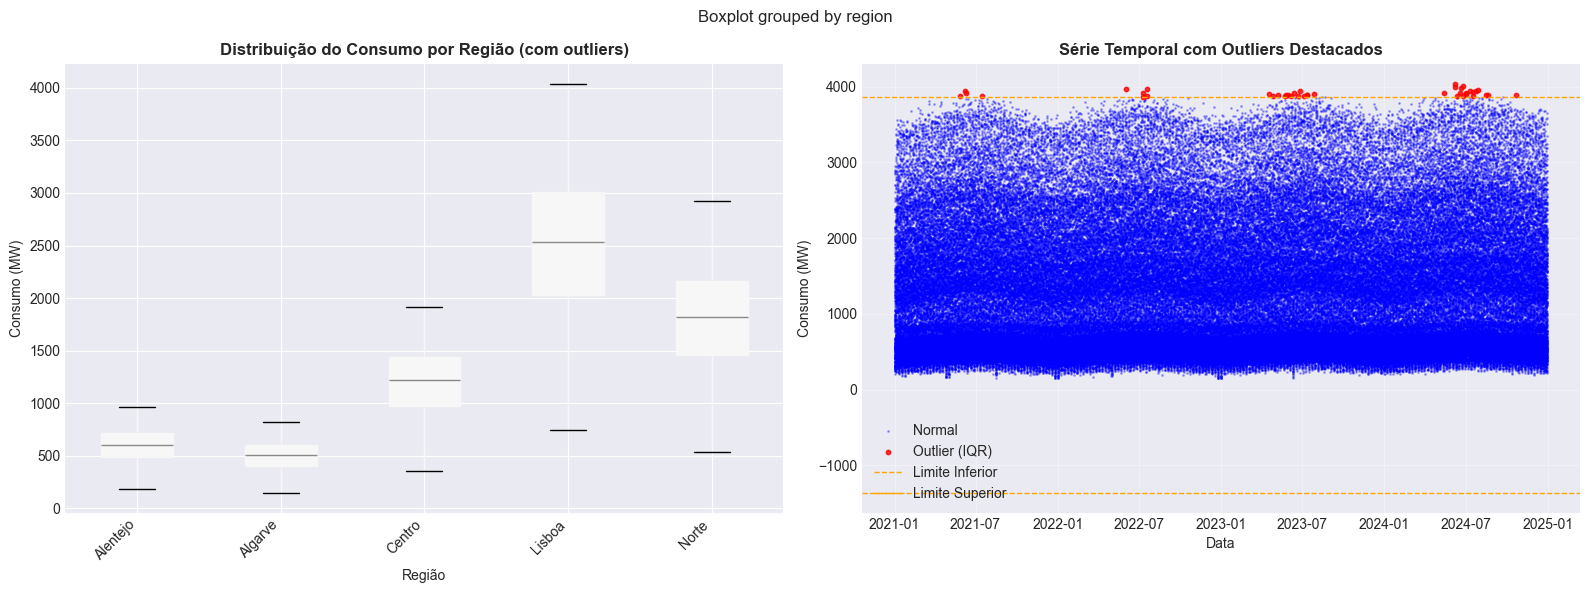

In [7]:
# Visualização de outliers
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot por região
df.boxplot(column='consumption_mw', by='region', ax=axes[0], patch_artist=True)
axes[0].set_title('Distribuição do Consumo por Região (com outliers)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Região')
axes[0].set_ylabel('Consumo (MW)')
axes[0].tick_params(axis='x', rotation=45)
plt.sca(axes[0])
plt.xticks(rotation=45, ha='right')

# Scatter plot temporal de outliers (IQR)
df['is_outlier'] = (df['consumption_mw'] < lower_bound) | (df['consumption_mw'] > upper_bound)
normal_data = df[~df['is_outlier']]
outlier_data = df[df['is_outlier']]

axes[1].scatter(normal_data['timestamp'], normal_data['consumption_mw'], 
                alpha=0.3, s=1, label='Normal', color='blue')
axes[1].scatter(outlier_data['timestamp'], outlier_data['consumption_mw'], 
                alpha=0.8, s=10, label='Outlier (IQR)', color='red')
axes[1].axhline(lower_bound, color='orange', linestyle='--', linewidth=1, label='Limite Inferior')
axes[1].axhline(upper_bound, color='orange', linestyle='--', linewidth=1, label='Limite Superior')
axes[1].set_title('Série Temporal com Outliers Destacados', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Data')
axes[1].set_ylabel('Consumo (MW)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Limpar coluna temporária
df.drop('is_outlier', axis=1, inplace=True)

## 6. Análise de Padrões Temporais

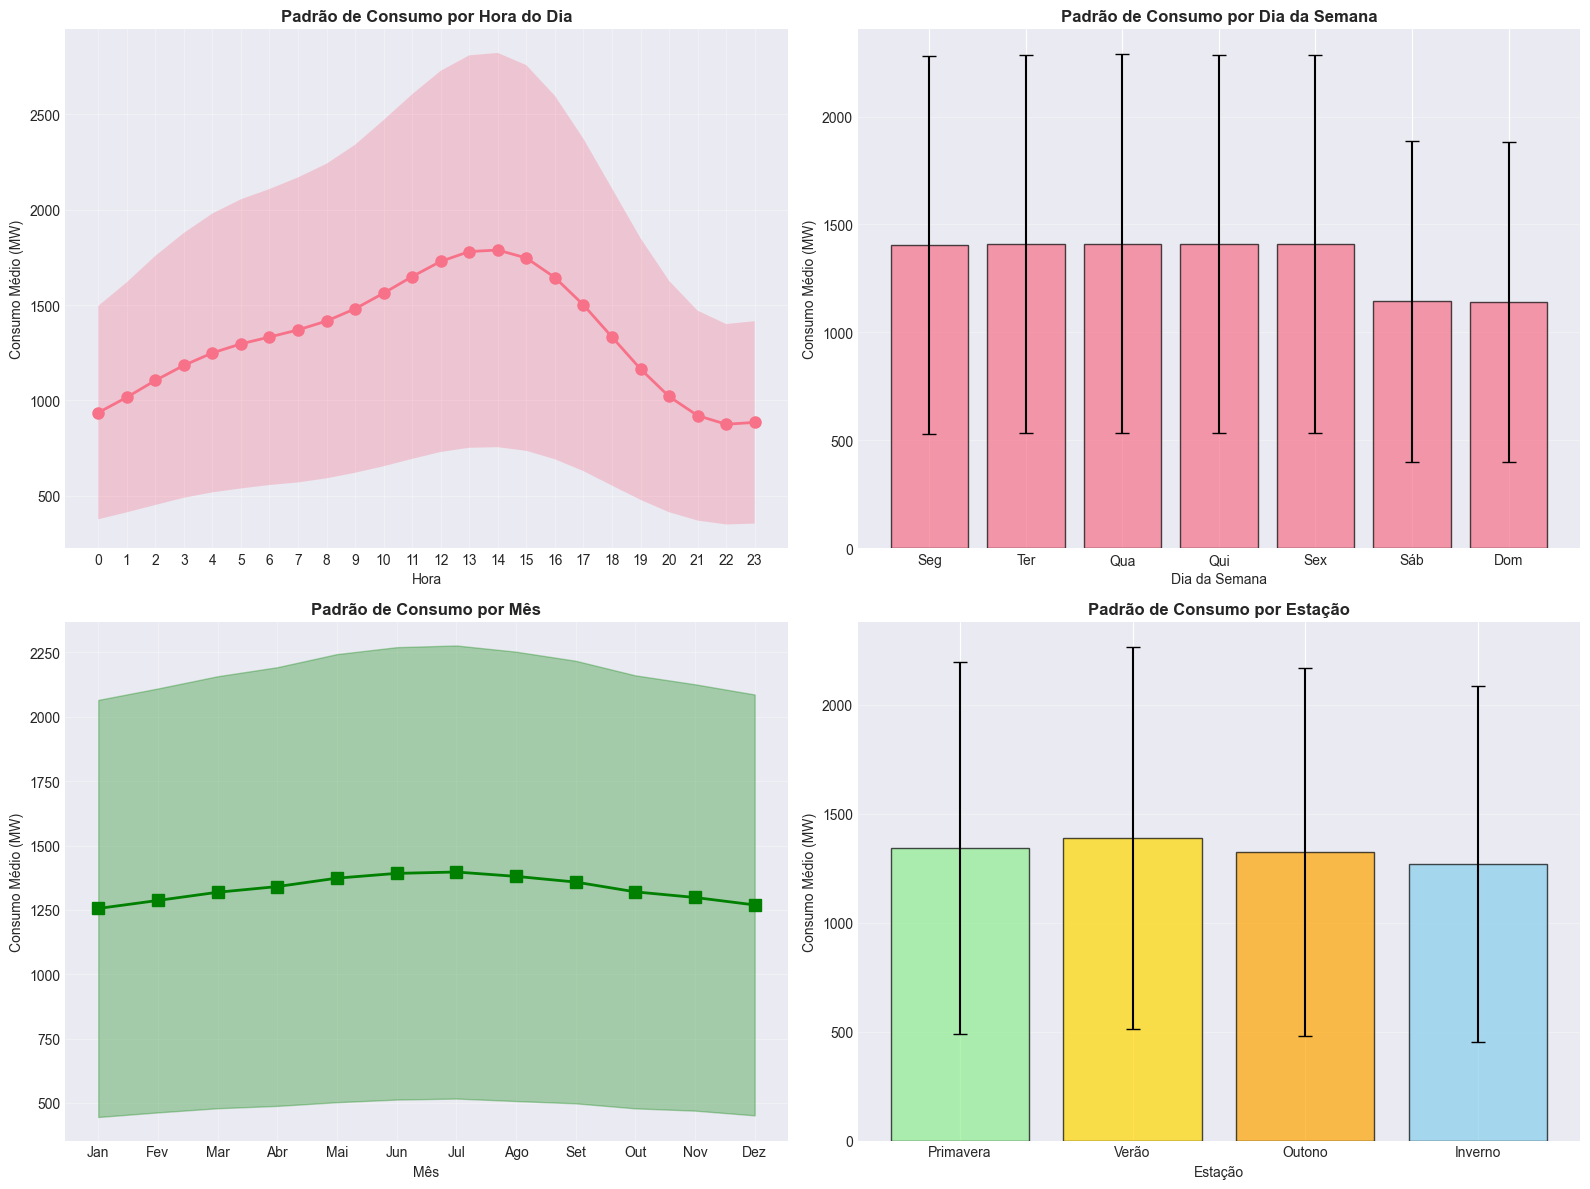


📊 RESUMO DE PADRÕES TEMPORAIS

Hora de maior consumo: 14h (1788.50 MW)
Hora de menor consumo: 22h (874.82 MW)

Dia com maior consumo: Qua (1410.94 MW)
Dia com menor consumo: Dom (1142.37 MW)

Mês de maior consumo: Jul (1397.06 MW)
Mês de menor consumo: Jan (1255.43 MW)

Estação de maior consumo: Verão (1389.63 MW)
Estação de menor consumo: Inverno (1269.91 MW)


In [8]:
# Padrões por hora, dia da semana, mês, estação
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Por Hora do Dia
hourly_avg = df.groupby('hour')['consumption_mw'].agg(['mean', 'std'])
axes[0, 0].plot(hourly_avg.index, hourly_avg['mean'], marker='o', linewidth=2, markersize=8)
axes[0, 0].fill_between(hourly_avg.index, 
                         hourly_avg['mean'] - hourly_avg['std'],
                         hourly_avg['mean'] + hourly_avg['std'],
                         alpha=0.3)
axes[0, 0].set_title('Padrão de Consumo por Hora do Dia', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Hora')
axes[0, 0].set_ylabel('Consumo Médio (MW)')
axes[0, 0].set_xticks(range(0, 24))
axes[0, 0].grid(True, alpha=0.3)

# 2. Por Dia da Semana
day_names = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
daily_avg = df.groupby('day_of_week')['consumption_mw'].agg(['mean', 'std'])
axes[0, 1].bar(daily_avg.index, daily_avg['mean'], yerr=daily_avg['std'], 
               capsize=5, alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Padrão de Consumo por Dia da Semana', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Dia da Semana')
axes[0, 1].set_ylabel('Consumo Médio (MW)')
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(day_names)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Por Mês
month_names = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
monthly_avg = df.groupby('month')['consumption_mw'].agg(['mean', 'std'])
axes[1, 0].plot(monthly_avg.index, monthly_avg['mean'], marker='s', linewidth=2, markersize=8, color='green')
axes[1, 0].fill_between(monthly_avg.index,
                         monthly_avg['mean'] - monthly_avg['std'],
                         monthly_avg['mean'] + monthly_avg['std'],
                         alpha=0.3, color='green')
axes[1, 0].set_title('Padrão de Consumo por Mês', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Mês')
axes[1, 0].set_ylabel('Consumo Médio (MW)')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(month_names)
axes[1, 0].grid(True, alpha=0.3)

# 4. Por Estação do Ano
season_order = ['Primavera', 'Verão', 'Outono', 'Inverno']
season_avg = df.groupby('season')['consumption_mw'].agg(['mean', 'std'])
season_avg = season_avg.reindex(season_order)
colors = ['#90EE90', '#FFD700', '#FFA500', '#87CEEB']
axes[1, 1].bar(range(len(season_avg)), season_avg['mean'], yerr=season_avg['std'],
               capsize=5, color=colors, edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Padrão de Consumo por Estação', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Estação')
axes[1, 1].set_ylabel('Consumo Médio (MW)')
axes[1, 1].set_xticks(range(4))
axes[1, 1].set_xticklabels(season_order)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Estatísticas
print('\n📊 RESUMO DE PADRÕES TEMPORAIS\n')
print(f"Hora de maior consumo: {hourly_avg['mean'].idxmax()}h ({hourly_avg['mean'].max():.2f} MW)")
print(f"Hora de menor consumo: {hourly_avg['mean'].idxmin()}h ({hourly_avg['mean'].min():.2f} MW)")
print(f"\nDia com maior consumo: {day_names[daily_avg['mean'].idxmax()]} ({daily_avg['mean'].max():.2f} MW)")
print(f"Dia com menor consumo: {day_names[daily_avg['mean'].idxmin()]} ({daily_avg['mean'].min():.2f} MW)")
print(f"\nMês de maior consumo: {month_names[monthly_avg['mean'].idxmax()-1]} ({monthly_avg['mean'].max():.2f} MW)")
print(f"Mês de menor consumo: {month_names[monthly_avg['mean'].idxmin()-1]} ({monthly_avg['mean'].min():.2f} MW)")
print(f"\nEstação de maior consumo: {season_avg['mean'].idxmax()} ({season_avg['mean'].max():.2f} MW)")
print(f"Estação de menor consumo: {season_avg['mean'].idxmin()} ({season_avg['mean'].min():.2f} MW)")

## 7. Decomposição Sazonal (STL)

🔬 DECOMPOSIÇÃO SAZONAL - LISBOA (90 dias)



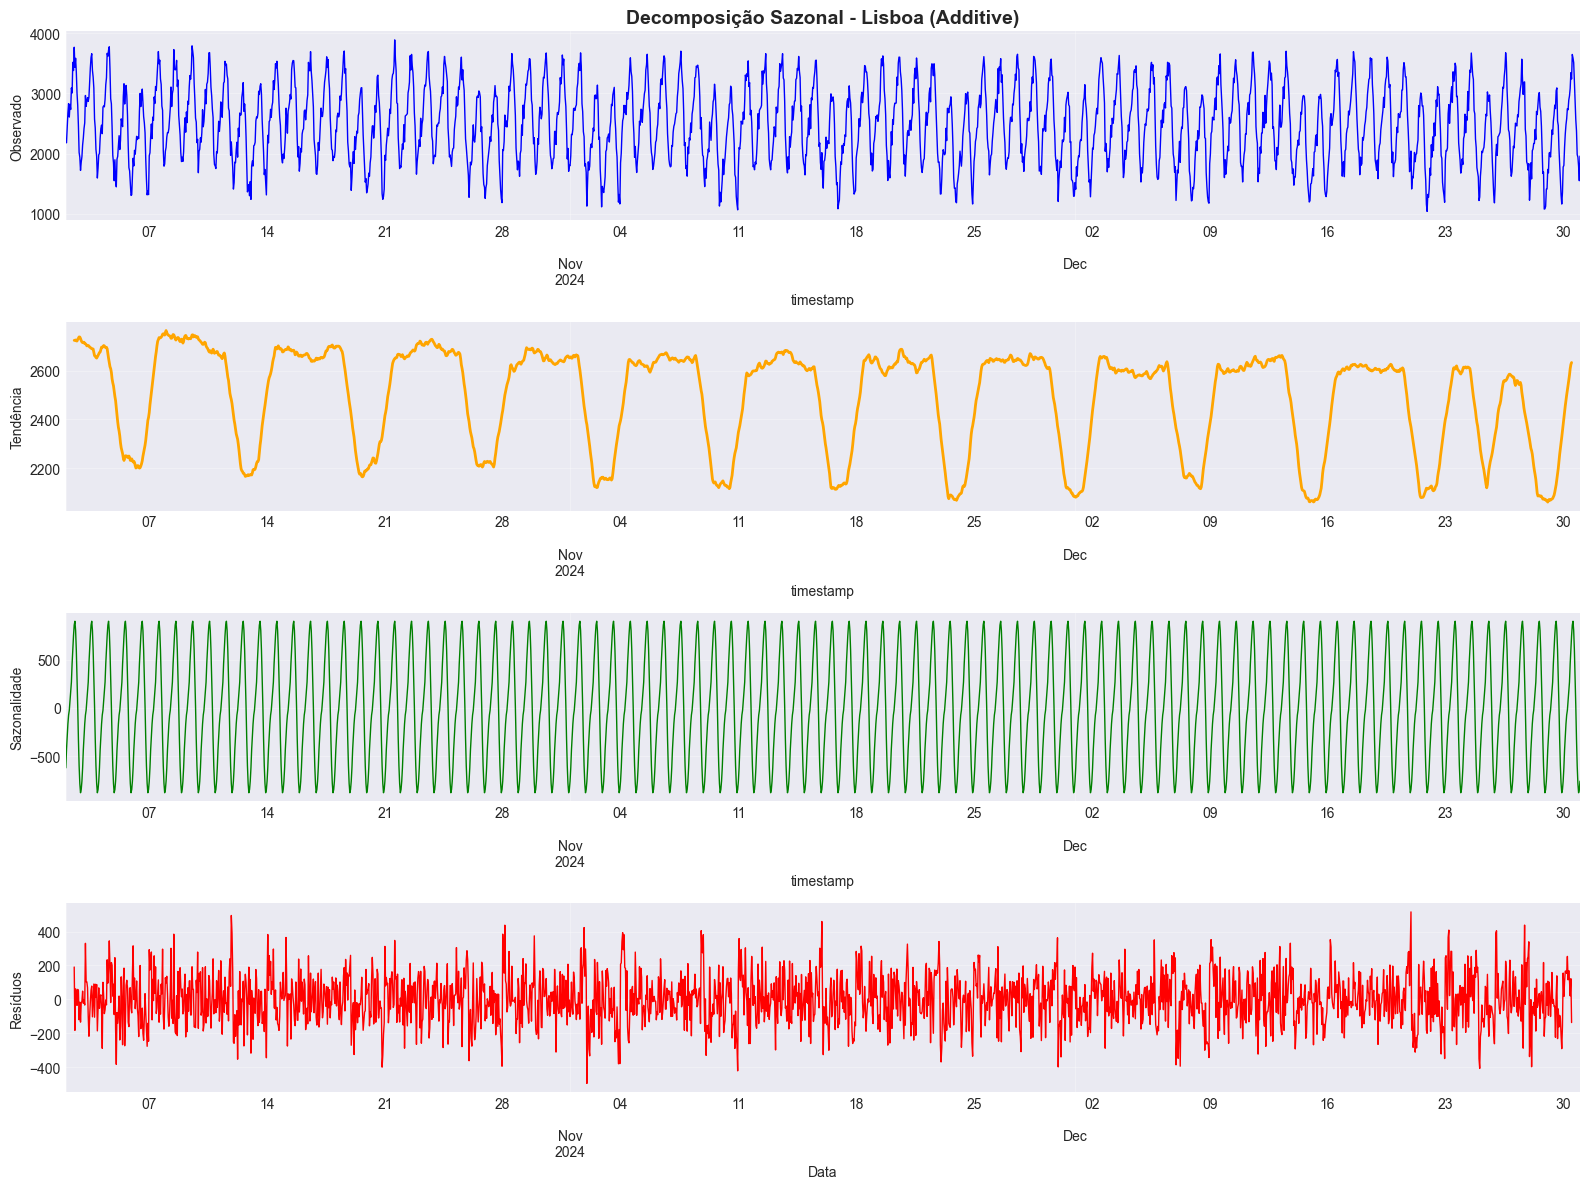

📈 Tendência:
   Média: 2491.08 MW
   Variação: 205.42 MW

🔄 Sazonalidade:
   Amplitude: 1772.53 MW
   Contribuição: 90.64%

📊 Resíduos:
   Média: 0.01 MW
   Desvio: 144.63 MW
   Variância explicada: 94.63%


In [9]:
# Decomposição sazonal para Lisboa (amostra de 90 dias)
print('🔬 DECOMPOSIÇÃO SAZONAL - LISBOA (90 dias)\n')

# Selecionar Lisboa e amostra recente
lisboa_data = df[df['region'] == 'Lisboa'].sort_values('timestamp').tail(90*24)
lisboa_ts = lisboa_data.set_index('timestamp')['consumption_mw']

# Decomposição (período de 24h)
decomposition = seasonal_decompose(lisboa_ts, model='additive', period=24)

# Plot
fig, axes = plt.subplots(4, 1, figsize=(16, 12))

# Original
decomposition.observed.plot(ax=axes[0], color='blue', linewidth=1)
axes[0].set_ylabel('Observado')
axes[0].set_title('Decomposição Sazonal - Lisboa (Additive)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Tendência
decomposition.trend.plot(ax=axes[1], color='orange', linewidth=2)
axes[1].set_ylabel('Tendência')
axes[1].grid(True, alpha=0.3)

# Sazonalidade
decomposition.seasonal.plot(ax=axes[2], color='green', linewidth=1)
axes[2].set_ylabel('Sazonalidade')
axes[2].grid(True, alpha=0.3)

# Resíduos
decomposition.resid.plot(ax=axes[3], color='red', linewidth=1)
axes[3].set_ylabel('Resíduos')
axes[3].set_xlabel('Data')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análise dos componentes
print(f"📈 Tendência:")
print(f"   Média: {decomposition.trend.mean():.2f} MW")
print(f"   Variação: {decomposition.trend.std():.2f} MW\n")

print(f"🔄 Sazonalidade:")
print(f"   Amplitude: {decomposition.seasonal.max() - decomposition.seasonal.min():.2f} MW")
print(f"   Contribuição: {(decomposition.seasonal.std() / lisboa_ts.std() * 100):.2f}%\n")

print(f"📊 Resíduos:")
print(f"   Média: {decomposition.resid.mean():.2f} MW")
print(f"   Desvio: {decomposition.resid.std():.2f} MW")
print(f"   Variância explicada: {(1 - decomposition.resid.var() / lisboa_ts.var()) * 100:.2f}%")

## 8. Autocorrelação (ACF/PACF)

📉 ANÁLISE DE AUTOCORRELAÇÃO - LISBOA (7 dias)



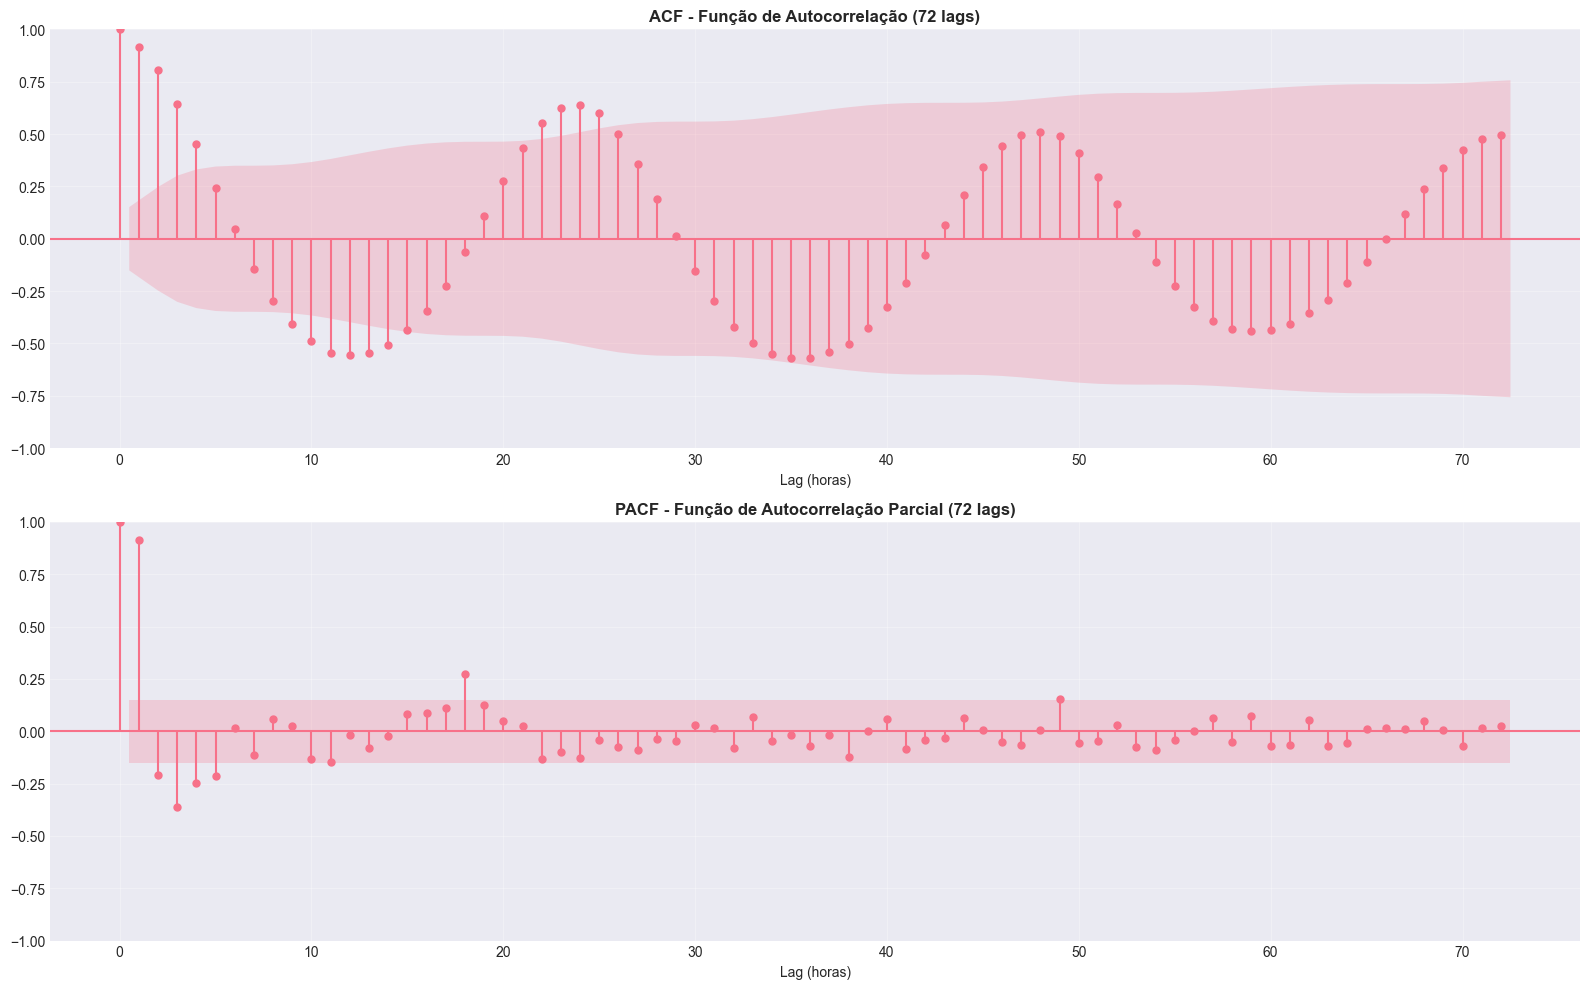

✓ ACF mostra correlação com lags anteriores (persistência temporal)
✓ PACF identifica lags significativos após remover influência de lags intermediários
✓ Picos em múltiplos de 24h indicam forte padrão diário


In [10]:
# ACF e PACF para Lisboa (amostra de 7 dias)
print('📉 ANÁLISE DE AUTOCORRELAÇÃO - LISBOA (7 dias)\n')

lisboa_sample = df[df['region'] == 'Lisboa'].sort_values('timestamp').tail(7*24)['consumption_mw']

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# ACF - Autocorrelation Function
plot_acf(lisboa_sample, lags=72, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF - Função de Autocorrelação (72 lags)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lag (horas)')
axes[0].grid(True, alpha=0.3)

# PACF - Partial Autocorrelation Function
plot_pacf(lisboa_sample, lags=72, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('PACF - Função de Autocorrelação Parcial (72 lags)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Lag (horas)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('✓ ACF mostra correlação com lags anteriores (persistência temporal)')
print('✓ PACF identifica lags significativos após remover influência de lags intermediários')
print('✓ Picos em múltiplos de 24h indicam forte padrão diário')

## 9. Análise Meteorológica Detalhada

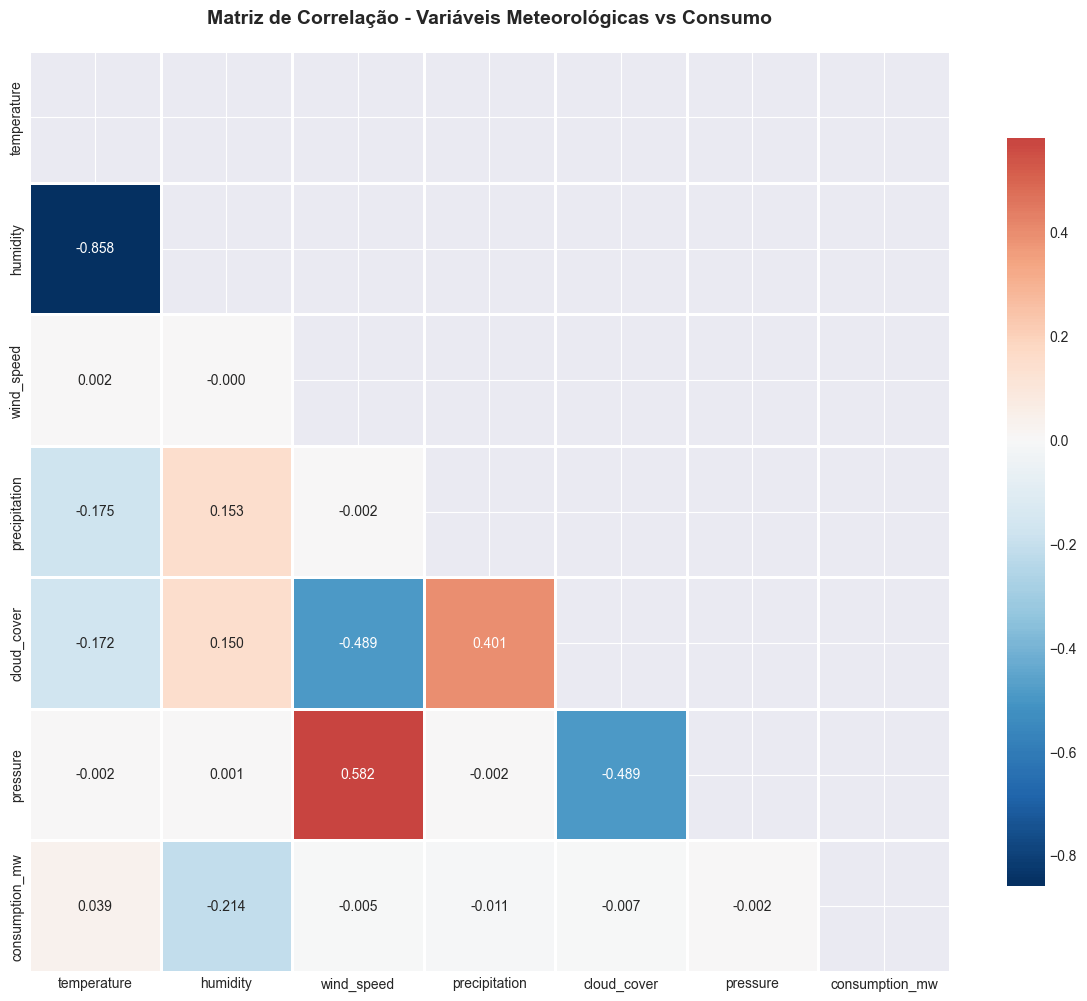


🌡️ CORRELAÇÕES COM CONSUMO:

temperature         : +0.0394  ↑  [Fraca]
pressure            : -0.0025  ↓  [Fraca]
wind_speed          : -0.0050  ↓  [Fraca]
cloud_cover         : -0.0066  ↓  [Fraca]
precipitation       : -0.0105  ↓  [Fraca]
humidity            : -0.2142  ↓  [Fraca]


In [11]:
# Correlação entre meteorologia e consumo
weather_cols = ['temperature', 'humidity', 'wind_speed', 'precipitation', 
                'cloud_cover', 'pressure', 'consumption_mw']
available_weather = [col for col in weather_cols if col in df.columns]

# Matriz de correlação
corr_matrix = df[available_weather].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', 
            cmap='RdBu_r', center=0, square=True, linewidths=1,
            cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação - Variáveis Meteorológicas vs Consumo', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print('\n🌡️ CORRELAÇÕES COM CONSUMO:\n')
consumption_corr = corr_matrix['consumption_mw'].drop('consumption_mw').sort_values(ascending=False)
for var, corr in consumption_corr.items():
    direction = '↑' if corr > 0 else '↓'
    strength = 'Forte' if abs(corr) > 0.5 else 'Moderada' if abs(corr) > 0.3 else 'Fraca'
    print(f"{var:20s}: {corr:+.4f}  {direction}  [{strength}]")

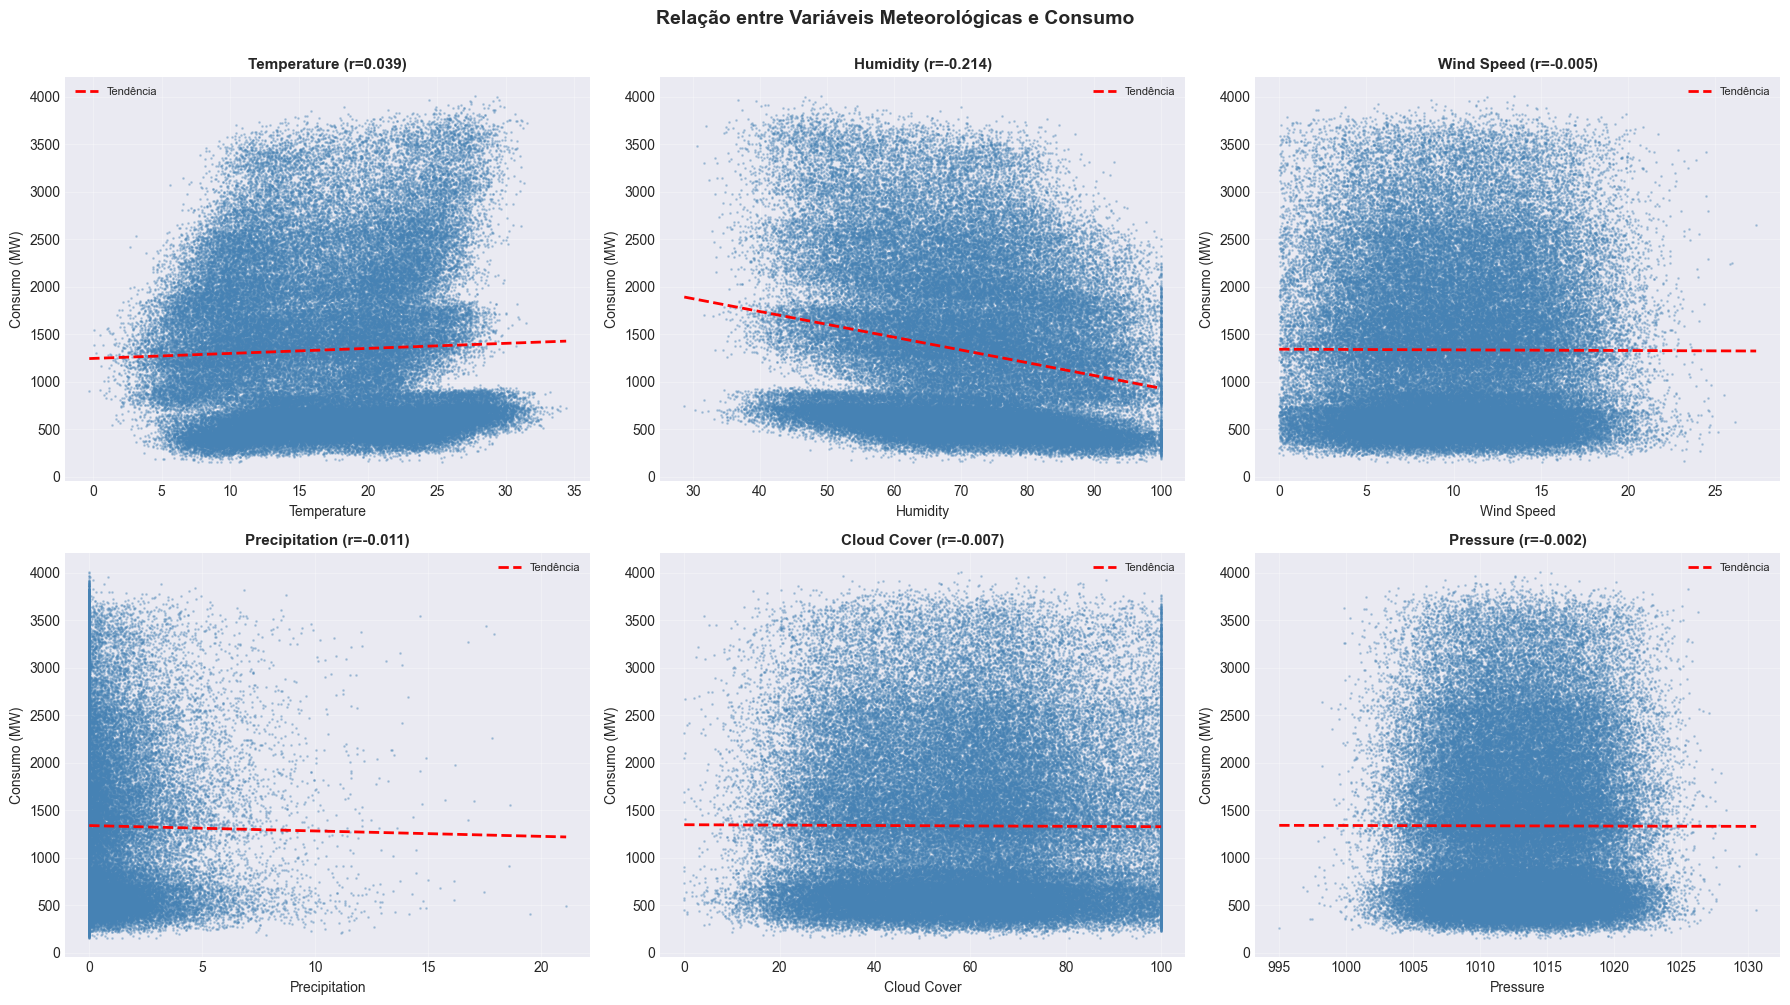

In [12]:
# Scatter plots: Consumo vs variáveis meteorológicas principais
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

weather_vars = [col for col in ['temperature', 'humidity', 'wind_speed', 
                                  'precipitation', 'cloud_cover', 'pressure'] if col in df.columns]

for idx, var in enumerate(weather_vars[:6]):
    # Sample para visualização (100k pontos)
    sample_df = df.sample(min(100000, len(df)), random_state=42)
    
    axes[idx].scatter(sample_df[var], sample_df['consumption_mw'], 
                     alpha=0.3, s=1, color='steelblue')
    
    # Linha de tendência
    z = np.polyfit(sample_df[var].dropna(), 
                   sample_df.loc[sample_df[var].dropna().index, 'consumption_mw'], 1)
    p = np.poly1d(z)
    x_trend = np.linspace(sample_df[var].min(), sample_df[var].max(), 100)
    axes[idx].plot(x_trend, p(x_trend), "r--", linewidth=2, label='Tendência')
    
    corr_val = df[[var, 'consumption_mw']].corr().iloc[0, 1]
    axes[idx].set_title(f'{var.replace("_", " ").title()} (r={corr_val:.3f})', 
                       fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(var.replace('_', ' ').title())
    axes[idx].set_ylabel('Consumo (MW)')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(loc='best', fontsize=8)

plt.suptitle('Relação entre Variáveis Meteorológicas e Consumo', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 10. Análise Comparativa entre Regiões

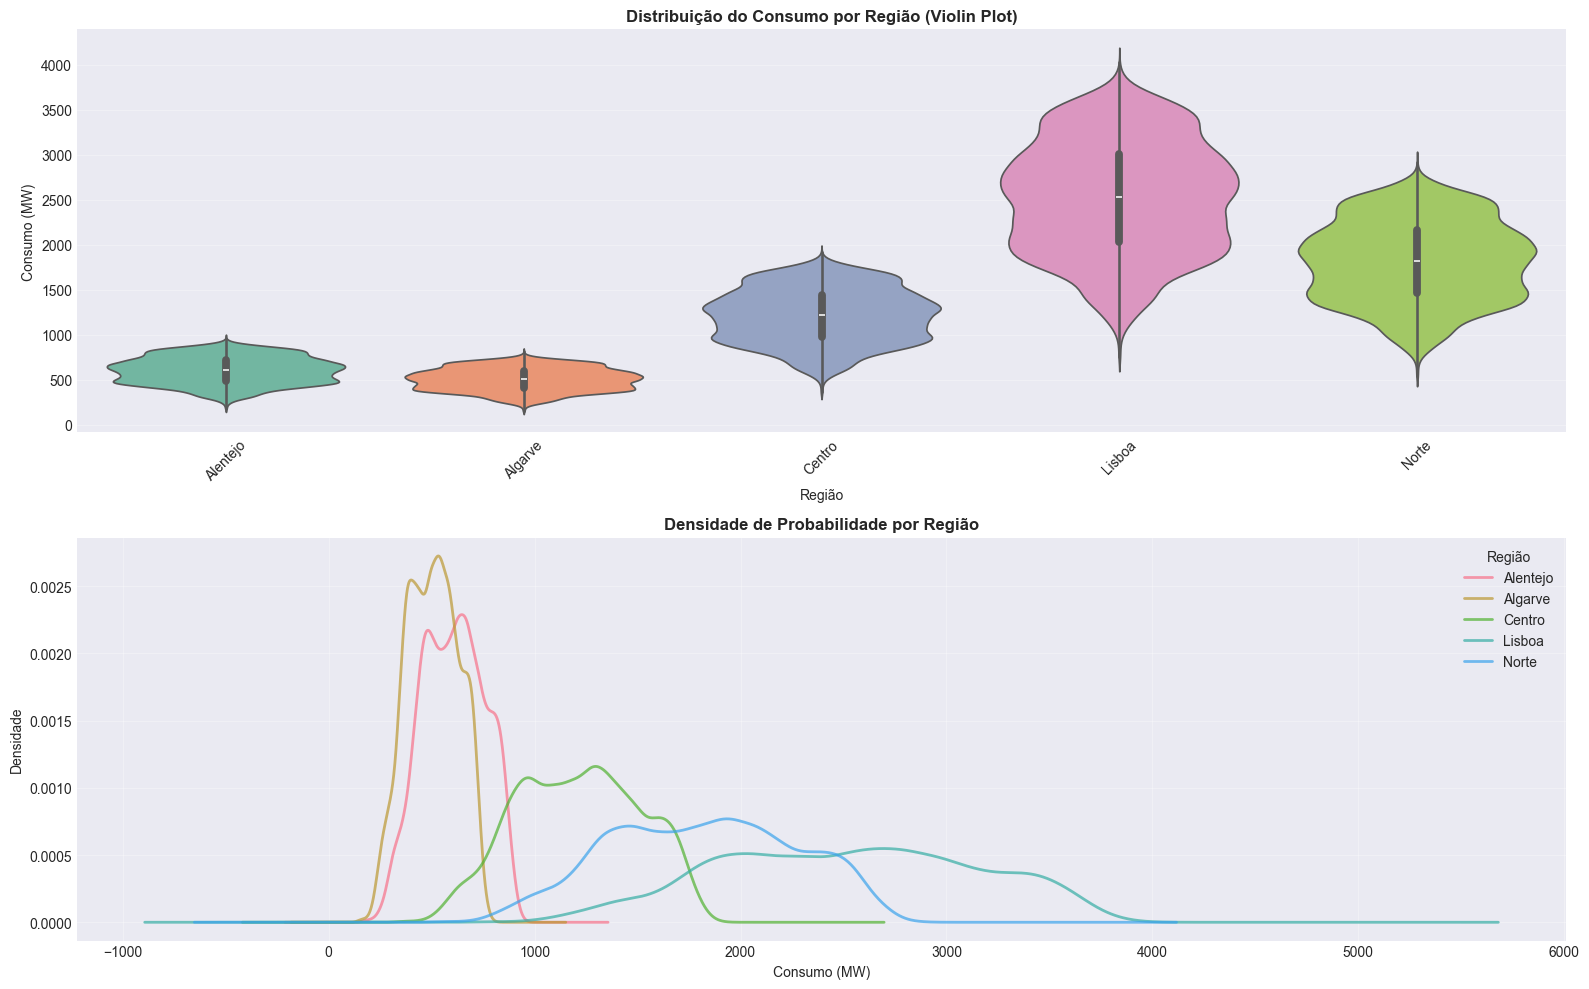

In [13]:
# Comparação de distribuições entre regiões
regions = df['region'].unique()
n_regions = len(regions)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Violin Plots
sns.violinplot(data=df, x='region', y='consumption_mw', ax=axes[0], palette='Set2')
axes[0].set_title('Distribuição do Consumo por Região (Violin Plot)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Região')
axes[0].set_ylabel('Consumo (MW)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# KDE por região (overlay)
for region in regions:
    region_data = df[df['region'] == region]['consumption_mw']
    region_data.plot(kind='kde', ax=axes[1], label=region, linewidth=2, alpha=0.7)

axes[1].set_title('Densidade de Probabilidade por Região', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Consumo (MW)')
axes[1].set_ylabel('Densidade')
axes[1].legend(title='Região', loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

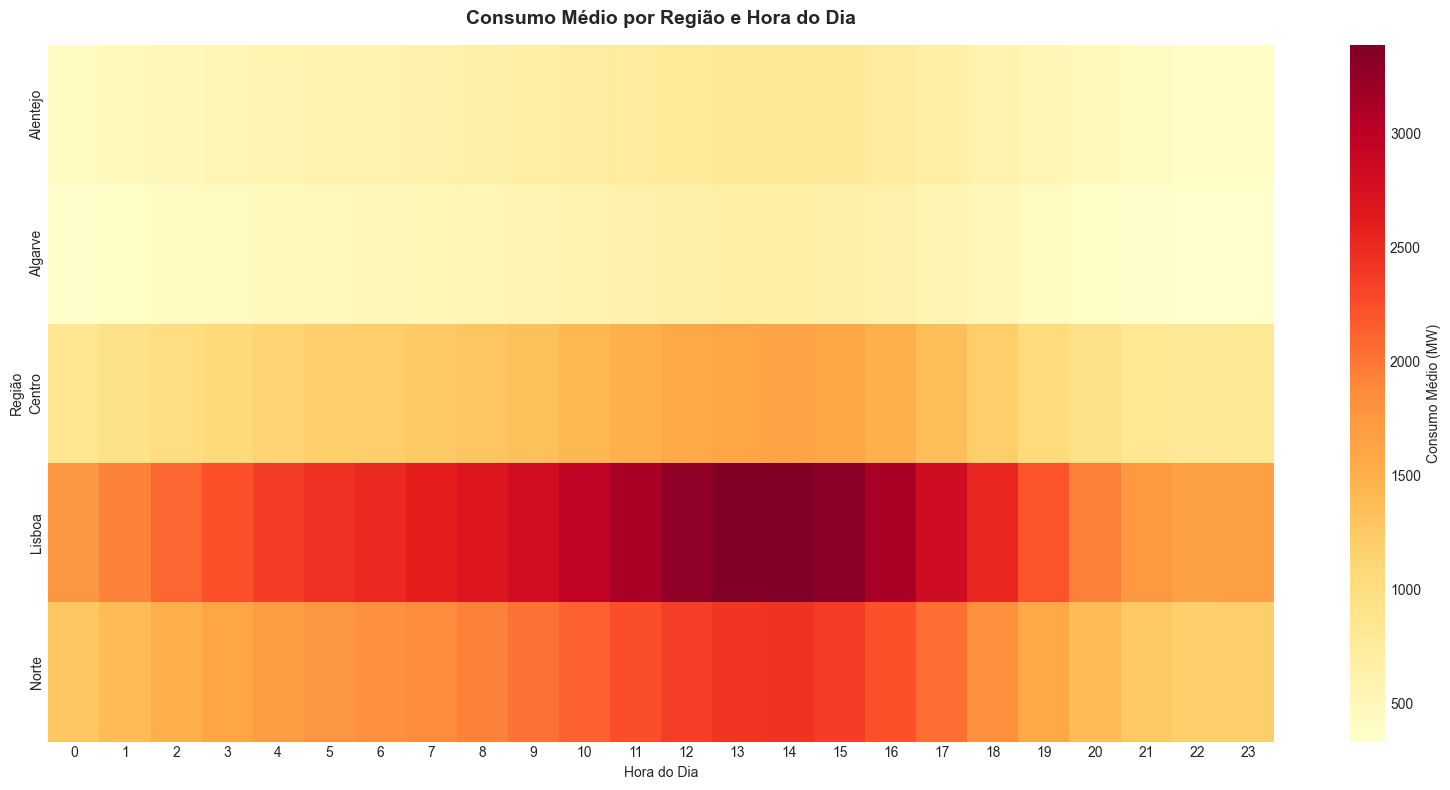

In [14]:
# Heatmap: Consumo médio por Região × Hora
pivot_data = df.groupby(['region', 'hour'])['consumption_mw'].mean().unstack()

plt.figure(figsize=(16, 8))
sns.heatmap(pivot_data, cmap='YlOrRd', annot=False, fmt='.0f', 
            cbar_kws={'label': 'Consumo Médio (MW)'})
plt.title('Consumo Médio por Região e Hora do Dia', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hora do Dia')
plt.ylabel('Região')
plt.tight_layout()
plt.show()


🗺️ CLUSTERING DE REGIÕES (PCA)



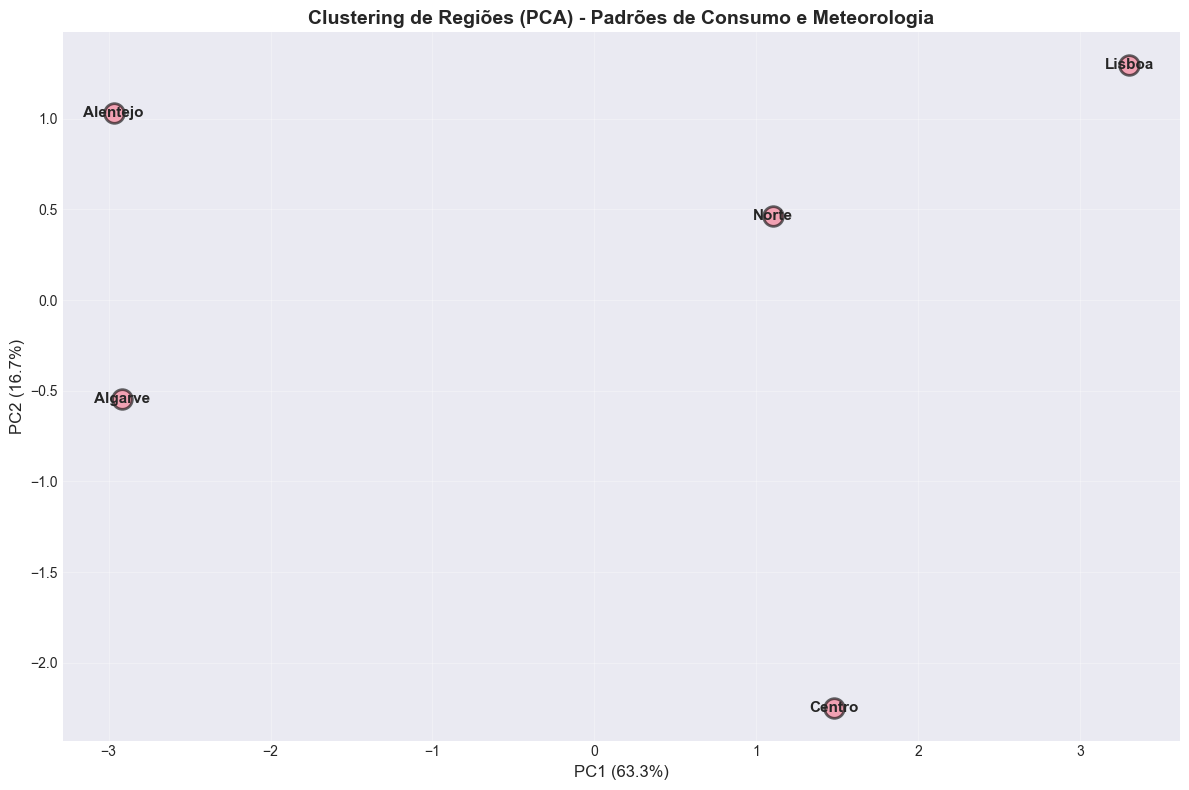

Variância explicada:
  PC1: 63.33%
  PC2: 16.66%
  Total: 79.99%


In [15]:
# Análise de similaridade entre regiões usando PCA
print('\n🗺️ CLUSTERING DE REGIÕES (PCA)\n')

# Criar features agregadas por região
region_features = df.groupby('region').agg({
    'consumption_mw': ['mean', 'std', 'min', 'max'],
    'temperature': ['mean', 'std'],
    'humidity': ['mean', 'std'],
    'wind_speed': ['mean', 'std']
}).values

# Normalizar
scaler = StandardScaler()
region_features_scaled = scaler.fit_transform(region_features)

# PCA
pca = PCA(n_components=2)
region_pca = pca.fit_transform(region_features_scaled)

# Plot
plt.figure(figsize=(12, 8))
plt.scatter(region_pca[:, 0], region_pca[:, 1], s=200, alpha=0.6, edgecolors='black', linewidth=2)

for i, region in enumerate(regions):
    plt.annotate(region, (region_pca[i, 0], region_pca[i, 1]), 
                fontsize=11, fontweight='bold', ha='center', va='center')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.title('Clustering de Regiões (PCA) - Padrões de Consumo e Meteorologia', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Variância explicada:")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"  Total: {sum(pca.explained_variance_ratio_)*100:.2f}%")

## 11. Resumo Executivo

In [16]:
print('='*90)
print('📊 RESUMO EXECUTIVO - ANÁLISE EXPLORATÓRIA AVANÇADA')
print('='*90)

print('\n1️⃣ DADOS')
print(f"   • Total de registros: {len(df):,}")
print(f"   • Período: {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"   • Regiões: {df['region'].nunique()}")
print(f"   • Frequência: Horária")

print('\n2️⃣ CONSUMO ENERGÉTICO')
print(f"   • Média: {df['consumption_mw'].mean():.2f} MW")
print(f"   • Mediana: {df['consumption_mw'].median():.2f} MW")
print(f"   • Desvio Padrão: {df['consumption_mw'].std():.2f} MW")
print(f"   • Range: [{df['consumption_mw'].min():.2f}, {df['consumption_mw'].max():.2f}] MW")
print(f"   • Coef. Variação: {(df['consumption_mw'].std()/df['consumption_mw'].mean()*100):.2f}%")

print('\n3️⃣ DISTRIBUIÇÃO')
skew = df['consumption_mw'].skew()
kurt = df['consumption_mw'].kurtosis()
print(f"   • Assimetria: {skew:.4f} {'(simétrica)' if abs(skew)<0.5 else '(assimétrica)'}")
print(f"   • Curtose: {kurt:.4f}")
print(f"   • Normalidade: Não-normal (dados temporais com sazonalidade)")

print('\n4️⃣ OUTLIERS (IQR)')
Q1 = df['consumption_mw'].quantile(0.25)
Q3 = df['consumption_mw'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['consumption_mw'] < Q1-1.5*IQR) | (df['consumption_mw'] > Q3+1.5*IQR)]
print(f"   • Quantidade: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")
print(f"   • Limites: [{Q1-1.5*IQR:.2f}, {Q3+1.5*IQR:.2f}] MW")

print('\n5️⃣ PADRÕES TEMPORAIS')
hourly_avg = df.groupby('hour')['consumption_mw'].mean()
daily_avg = df.groupby('day_of_week')['consumption_mw'].mean()
seasonal_avg = df.groupby('season')['consumption_mw'].mean()
print(f"   • Pico horário: {hourly_avg.idxmax()}h ({hourly_avg.max():.2f} MW)")
print(f"   • Vale horário: {hourly_avg.idxmin()}h ({hourly_avg.min():.2f} MW)")
day_names = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
print(f"   • Dia com maior consumo: {day_names[daily_avg.idxmax()]}")
print(f"   • Estação com maior consumo: {seasonal_avg.idxmax()}")
print(f"   • Forte sazonalidade diária (24h)")

print('\n6️⃣ CORRELAÇÕES METEOROLÓGICAS')
weather_vars = ['temperature', 'humidity', 'wind_speed']
for var in weather_vars:
    if var in df.columns:
        corr = df[[var, 'consumption_mw']].corr().iloc[0, 1]
        print(f"   • {var.title()}: {corr:+.4f}")

print('\n7️⃣ DECOMPOSIÇÃO SAZONAL (Lisboa - 90 dias)')
lisboa_data = df[df['region'] == 'Lisboa'].sort_values('timestamp').tail(90*24)
lisboa_ts = lisboa_data.set_index('timestamp')['consumption_mw']
decomp = seasonal_decompose(lisboa_ts, model='additive', period=24)
var_explained = (1 - decomp.resid.var() / lisboa_ts.var()) * 100
print(f"   • Variância explicada: {var_explained:.2f}%")
print(f"   • Forte componente sazonal diária")
print(f"   • Tendência estável no período")

print('\n8️⃣ REGIÕES')
region_stats = df.groupby('region')['consumption_mw'].mean().sort_values(ascending=False)
print(f"   • Maior consumo: {region_stats.index[0]} ({region_stats.iloc[0]:.2f} MW)")
print(f"   • Menor consumo: {region_stats.index[-1]} ({region_stats.iloc[-1]:.2f} MW)")
print(f"   • Razão máx/mín: {region_stats.iloc[0]/region_stats.iloc[-1]:.2f}x")

print('\n9️⃣ INSIGHTS PRINCIPAIS')
print("   ✓ Forte padrão diário (24h) em todas as regiões")
print("   ✓ Consumo maior em dias úteis vs fins de semana")
print("   ✓ Sazonalidade anual presente (Inverno > Verão em PT)")
print("   ✓ Temperatura é a variável meteorológica mais correlacionada")
print("   ✓ Outliers representam eventos anómalos ou feriados")
print("   ✓ Regiões apresentam padrões similares mas escalas diferentes")

print('\n🔟 RECOMENDAÇÕES PARA MODELAGEM')
print("   → Incluir features de lag (1h, 24h, 168h)")
print("   → Codificar hora/dia/mês de forma cíclica")
print("   → Considerar interações temperatura × hora")
print("   → Tratar outliers ou criar flag de anomalia")
print("   → Validação temporal (não aleatória)")
print("   → Considerar modelos específicos por região")

print('\n' + '='*90)
print('✅ ANÁLISE EXPLORATÓRIA AVANÇADA COMPLETA')
print('='*90)

📊 RESUMO EXECUTIVO - ANÁLISE EXPLORATÓRIA AVANÇADA

1️⃣ DADOS
   • Total de registros: 175,205
   • Período: 2021-01-01 00:00:00 → 2024-12-31 00:00:00
   • Regiões: 5
   • Frequência: Horária

2️⃣ CONSUMO ENERGÉTICO
   • Média: 1332.59 MW
   • Mediana: 1146.74 MW
   • Desvio Padrão: 849.47 MW
   • Range: [150.00, 4036.51] MW
   • Coef. Variação: 63.75%

3️⃣ DISTRIBUIÇÃO
   • Assimetria: 0.7874 (assimétrica)
   • Curtose: -0.3166
   • Normalidade: Não-normal (dados temporais com sazonalidade)

4️⃣ OUTLIERS (IQR)
   • Quantidade: 41 (0.02%)
   • Limites: [-1358.94, 3868.06] MW

5️⃣ PADRÕES TEMPORAIS
   • Pico horário: 14h (1788.50 MW)
   • Vale horário: 22h (874.82 MW)
   • Dia com maior consumo: Qua
   • Estação com maior consumo: Verão
   • Forte sazonalidade diária (24h)

6️⃣ CORRELAÇÕES METEOROLÓGICAS
   • Temperature: +0.0394
   • Humidity: -0.2142
   • Wind_Speed: -0.0050

7️⃣ DECOMPOSIÇÃO SAZONAL (Lisboa - 90 dias)
   • Variância explicada: 94.63%
   • Forte componente sazonal diá